In [1]:
from src.training.foundation_models import FOUNDATION_MODELS

In [2]:
import os
from pathlib import Path

PROJECT_DIR = Path(os.environ['PROJECT_DIR'])
PAPER_DIR = PROJECT_DIR / 'paper'

In [3]:
from copy import deepcopy
from tqdm.auto import tqdm

sizes = deepcopy(FOUNDATION_MODELS)
for size in tqdm(FOUNDATION_MODELS, desc='Processing models'):
    for model_name in tqdm(FOUNDATION_MODELS[size], leave=False):
        model = FOUNDATION_MODELS[size][model_name]()
        sizes[size][model_name] = sum(p.numel() for p in model.parameters())

Processing models:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.10/site-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


  0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

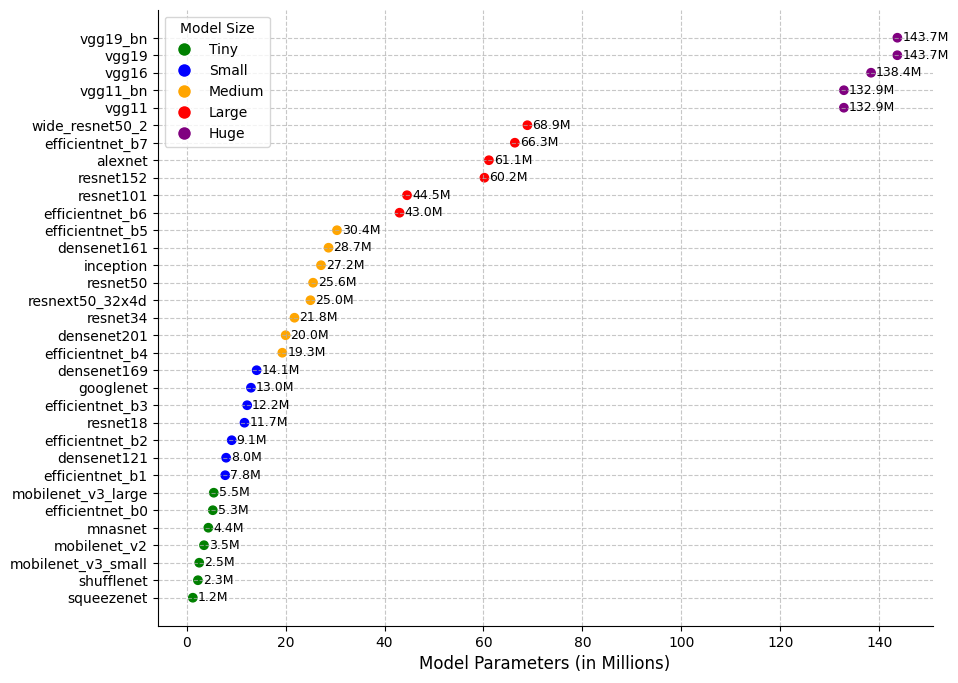

In [4]:
import matplotlib.pyplot as plt

colors = {
    'tiny': 'green', 
    'small': 'blue', 
    'medium': 'orange', 
    'large': 'red', 
    'huge': 'purple'
}

model_names = []
sizes_millions = []
color_list = []

for size_group, models in sizes.items():
    for model, size in models.items():
        model_names.append(model)
        sizes_millions.append(size / 1e6)
        color_list.append(colors[size_group])

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(sizes_millions, model_names, c=color_list)

# Adding labels
for i, size in enumerate(sizes_millions):
    ax.text(size + 1, i, f"{size:.1f}M", fontsize=9, va='center')

# Setting grid, labels, and title
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_xlabel('Model Parameters (in Millions)', fontsize=12)
# ax.set_title('Model Sizes of Various Architectures with Colorized Size Ranges', fontsize=14)

legend_handles = [
    plt.Line2D(
        [0], [0], marker='o', color='w', 
        markerfacecolor=colors[key], markersize=10, 
        label=key.capitalize()
    ) 
    for key in colors
]
ax.legend(handles=legend_handles, title="Model Size")
ax.spines[['right', 'top']].set_visible(False)

plt.savefig(PAPER_DIR / 'figures/foundation-models-by-size.pdf', bbox_inches='tight')
plt.show()